<a href="https://colab.research.google.com/github/francivility/BDA-Final-Proj./blob/main/Week_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install kaggle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import zipfile

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
from google.colab import files

print('Please upload the OULAD zip file...')
print('Download it first from: https://analyse.kmi.open.ac.uk/open-dataset')
uploaded = files.upload()

Please upload the OULAD zip file...
Download it first from: https://analyse.kmi.open.ac.uk/open-dataset


Saving anonymisedData.zip to anonymisedData.zip


In [ ]:
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('/content/oulad/')

print('Extracted files:')
for f in os.listdir('/content/oulad/'):
    size = os.path.getsize(f'/content/oulad/{f}') / 1024 / 1024
    print(f'  {f}  ({size:.2f} MB)')

Extracted files:
  assessments.csv  (0.01 MB)
  vle.csv  (0.25 MB)
  courses.csv  (0.00 MB)
  studentRegistration.csv  (1.06 MB)
  studentInfo.csv  (3.30 MB)
  studentAssessment.csv  (5.43 MB)
  studentVle.csv  (432.81 MB)


In [ ]:
base_path = '/content/oulad/'

student_info       = pd.read_csv(base_path + 'studentInfo.csv')
student_vle        = pd.read_csv(base_path + 'studentVle.csv')
student_assessment = pd.read_csv(base_path + 'studentAssessment.csv')
student_reg        = pd.read_csv(base_path + 'studentRegistration.csv')
assessments        = pd.read_csv(base_path + 'assessments.csv')
vle                = pd.read_csv(base_path + 'vle.csv')
courses            = pd.read_csv(base_path + 'courses.csv')

print('=== DATASET LOADED SUCCESSFULLY ===')
print(f'studentInfo       : {student_info.shape[0]:,} rows x {student_info.shape[1]} columns')
print(f'studentVle        : {student_vle.shape[0]:,} rows x {student_vle.shape[1]} columns')
print(f'studentAssessment : {student_assessment.shape[0]:,} rows x {student_assessment.shape[1]} columns')
print(f'studentReg        : {student_reg.shape[0]:,} rows x {student_reg.shape[1]} columns')
print(f'assessments       : {assessments.shape[0]:,} rows x {assessments.shape[1]} columns')
print(f'vle               : {vle.shape[0]:,} rows x {vle.shape[1]} columns')
print(f'courses           : {courses.shape[0]:,} rows x {courses.shape[1]} columns')

total_rows = (student_info.shape[0] + student_vle.shape[0] +
              student_assessment.shape[0] + student_reg.shape[0] +
              assessments.shape[0] + vle.shape[0] + courses.shape[0])
print(f'\nTOTAL ROWS (all files combined): {total_rows:,}')

=== DATASET LOADED SUCCESSFULLY ===
studentInfo       : 32,593 rows x 12 columns
studentVle        : 10,655,280 rows x 6 columns
studentAssessment : 173,912 rows x 5 columns
studentReg        : 32,593 rows x 5 columns
assessments       : 206 rows x 6 columns
vle               : 6,364 rows x 6 columns
courses           : 22 rows x 3 columns

TOTAL ROWS (all files combined): 10,900,970


In [ ]:
print('=== studentInfo.csv Preview ===')
display(student_info.head())
print()
print('Columns:', list(student_info.columns))
print()
print('Target variable (final_result) distribution:')
print(student_info['final_result'].value_counts())

=== studentInfo.csv Preview ===


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Target variable (final_result) distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [ ]:
print('=== MISSING VALUES PER FILE ===')

datasets = {
    'studentInfo': student_info,
    'studentVle': student_vle,
    'studentAssessment': student_assessment,
    'studentRegistration': student_reg
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n{name}:')
        print(missing)
    else:
        print(f'\n{name}: No missing values found.')

=== MISSING VALUES PER FILE ===

studentInfo:
imd_band    1111
dtype: int64

studentVle: No missing values found.

studentAssessment:
score    173
dtype: int64

studentRegistration:
date_registration         45
date_unregistration    22521
dtype: int64


In [ ]:
print(f'studentInfo rows BEFORE cleaning: {student_info.shape[0]:,}')

# Step 1: Drop duplicates
student_info_clean = student_info.drop_duplicates()
print(f'After removing duplicates: {student_info_clean.shape[0]:,}')

# Step 2: Fill missing imd_band
student_info_clean['imd_band'] = student_info_clean['imd_band'].fillna('Unknown')

# Step 3: Drop rows with missing critical columns
student_info_clean = student_info_clean.dropna(subset=['studied_credits', 'num_of_prev_attempts'])
print(f'After dropping critical nulls: {student_info_clean.shape[0]:,}')

# Step 4: Create binary dropout label
student_info_clean['is_dropout'] = (student_info_clean['final_result'] == 'Withdrawn').astype(int)

# Step 5: Create risk level classification
def classify_risk(result):
    if result == 'Withdrawn':
        return 'High Risk'
    elif result == 'Fail':
        return 'Medium Risk'
    else:
        return 'Low Risk'

student_info_clean['risk_level'] = student_info_clean['final_result'].apply(classify_risk)

print(f'\nstudentInfo rows AFTER cleaning: {student_info_clean.shape[0]:,}')
print(f'New columns added: is_dropout, risk_level')
print()
print('Risk Level Distribution:')
print(student_info_clean['risk_level'].value_counts())

studentInfo rows BEFORE cleaning: 32,593
After removing duplicates: 32,593
After dropping critical nulls: 32,593

studentInfo rows AFTER cleaning: 32,593
New columns added: is_dropout, risk_level

Risk Level Distribution:
risk_level
Low Risk       15385
High Risk      10156
Medium Risk     7052
Name: count, dtype: int64


In [ ]:
print(f'studentAssessment rows BEFORE cleaning: {student_assessment.shape[0]:,}')

# Step 1: Drop duplicates
assessment_clean = student_assessment.drop_duplicates()

# Step 2: Drop rows where score is missing
assessment_clean = assessment_clean.dropna(subset=['score'])

# Step 3: Remove scores outside 0-100
assessment_clean = assessment_clean[
    (assessment_clean['score'] >= 0) & (assessment_clean['score'] <= 100)
]

# Step 4: Fill missing date_submitted with median
median_date = assessment_clean['date_submitted'].median()
assessment_clean['date_submitted'] = assessment_clean['date_submitted'].fillna(median_date)

print(f'studentAssessment rows AFTER cleaning: {assessment_clean.shape[0]:,}')
print()
print('Score statistics:')
print(assessment_clean['score'].describe())

studentAssessment rows BEFORE cleaning: 173,912
studentAssessment rows AFTER cleaning: 173,739

Score statistics:
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64


In [ ]:
print(f'studentVle rows BEFORE cleaning: {student_vle.shape[0]:,}')

# Step 1: Drop duplicates
vle_clean = student_vle.drop_duplicates()

# Step 2: Remove rows with missing or zero clicks
vle_clean = vle_clean.dropna(subset=['sum_click'])
vle_clean = vle_clean[vle_clean['sum_click'] > 0]

# Step 3: Remove extreme outliers using IQR
Q1 = vle_clean['sum_click'].quantile(0.25)
Q3 = vle_clean['sum_click'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR
vle_clean = vle_clean[vle_clean['sum_click'] <= upper_bound]

print(f'studentVle rows AFTER cleaning: {vle_clean.shape[0]:,}')
print()
print('Sum click statistics after cleaning:')
print(vle_clean['sum_click'].describe())

studentVle rows BEFORE cleaning: 10,655,280
studentVle rows AFTER cleaning: 9,398,040

Sum click statistics after cleaning:
count    9.398040e+06
mean     2.625069e+00
std      2.473275e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      1.300000e+01
Name: sum_click, dtype: float64


In [ ]:
# Aggregate VLE clicks per student
vle_agg = vle_clean.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique')
).reset_index()

# Aggregate assessment scores per student
assessment_agg = assessment_clean.groupby('id_student').agg(
    avg_score=('score', 'mean'),
    total_assessments=('id_assessment', 'count'),
    late_submissions=('is_banked', 'sum')
).reset_index()

# Merge all into master dataset
master_df = student_info_clean.merge(
    vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='left'
)
master_df = master_df.merge(assessment_agg, on='id_student', how='left')

# Fill nulls from left joins
fill_cols = ['total_clicks', 'active_days', 'avg_score', 'total_assessments', 'late_submissions']
master_df[fill_cols] = master_df[fill_cols].fillna(0)

print(f'=== MASTER DATASET ===')
print(f'Total rows   : {master_df.shape[0]:,}')
print(f'Total columns: {master_df.shape[1]}')
print()
display(master_df.head())

=== MASTER DATASET ===
Total rows   : 32,593
Total columns: 19



,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,is_dropout,risk_level,total_clicks,active_days,avg_score,total_assessments,late_submissions
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,Low Risk,572.0,40.0,82.0,5.0,0.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,Low Risk,1167.0,80.0,66.4,5.0,0.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,High Risk,216.0,12.0,0.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,Low Risk,1816.0,123.0,76.0,5.0,0.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,Low Risk,891.0,70.0,54.4,5.0,0.0


In [ ]:
master_df.to_csv('/content/oulad_cleaned_master.csv', index=False)
print('Saved: oulad_cleaned_master.csv')
print(f'Final shape: {master_df.shape[0]:,} rows x {master_df.shape[1]} columns')
print()
print('=== NULL CHECK ===')
nulls = master_df.isnull().sum()
print(nulls[nulls > 0] if nulls[nulls > 0].any() else 'No missing values in master dataset.')

Saved: oulad_cleaned_master.csv
Final shape: 32,593 rows x 19 columns

=== NULL CHECK ===
No missing values in master dataset.


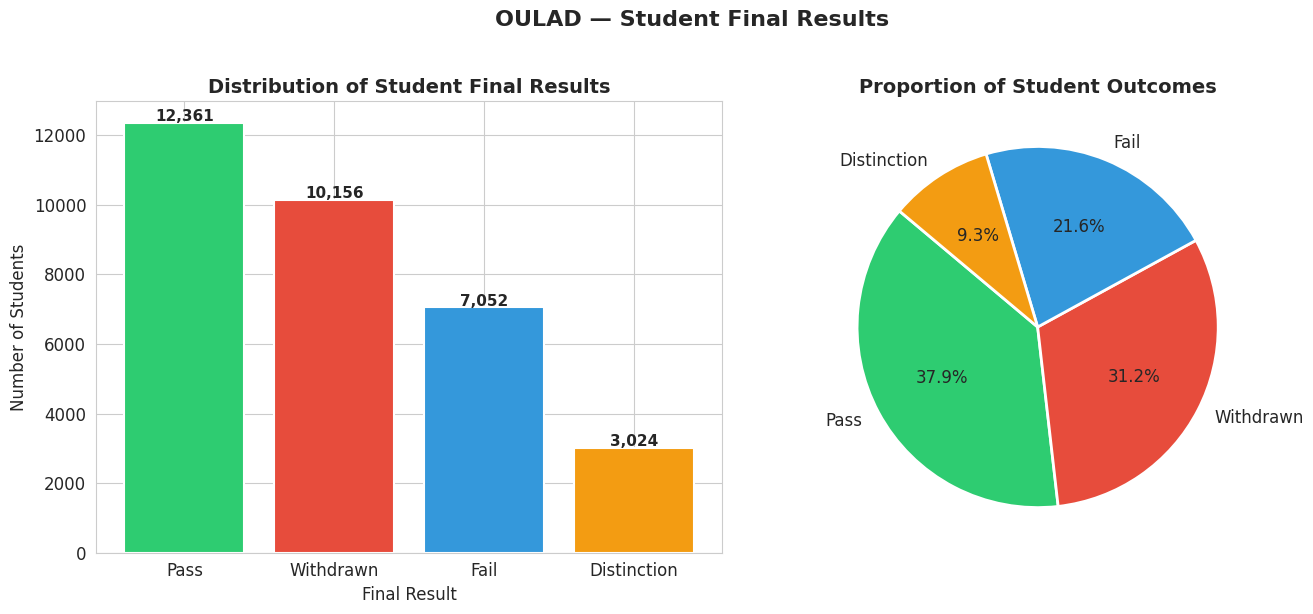

Saved: viz1_final_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

result_counts = master_df['final_result'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

axes[0].bar(result_counts.index, result_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution of Student Final Results', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(result_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(result_counts.values, labels=result_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of Student Outcomes', fontsize=14, fontweight='bold')

plt.suptitle('OULAD — Student Final Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/viz1_final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz1_final_results.png')

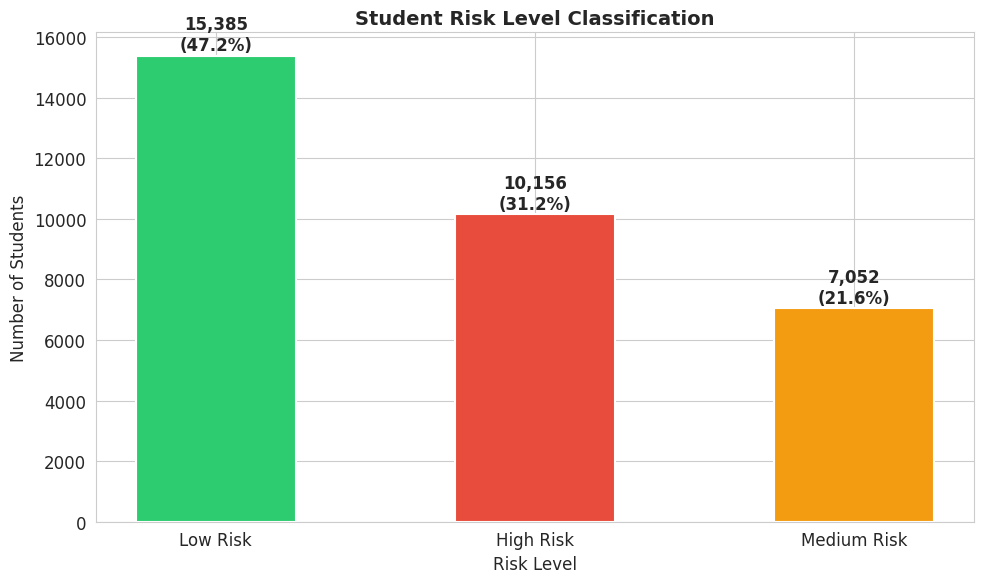

Saved: viz2_risk_levels.png


In [ ]:
risk_counts = master_df['risk_level'].value_counts()
risk_colors = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#2ecc71'}
colors_ordered = [risk_colors[r] for r in risk_counts.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(risk_counts.index, risk_counts.values,
               color=colors_ordered, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, risk_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}\n({val/len(master_df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Student Risk Level Classification', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('/content/viz2_risk_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz2_risk_levels.png')

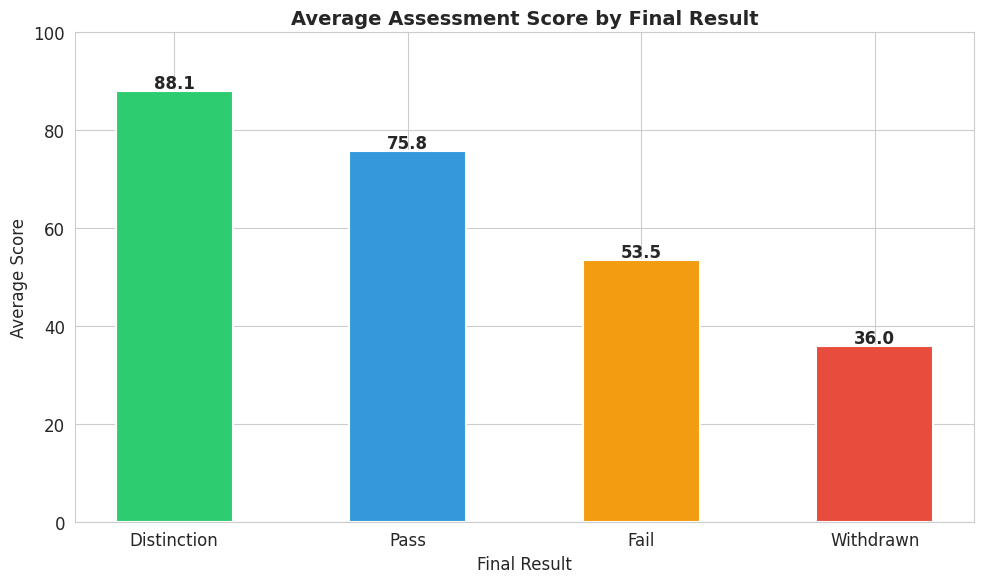

Saved: viz3_avg_score.png


In [ ]:
score_by_result = master_df.groupby('final_result')['avg_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(score_by_result.index, score_by_result.values,
               color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
               edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, score_by_result.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.title('Average Assessment Score by Final Result', fontsize=14, fontweight='bold')
plt.xlabel('Final Result')
plt.ylabel('Average Score')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('/content/viz3_avg_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz3_avg_score.png')

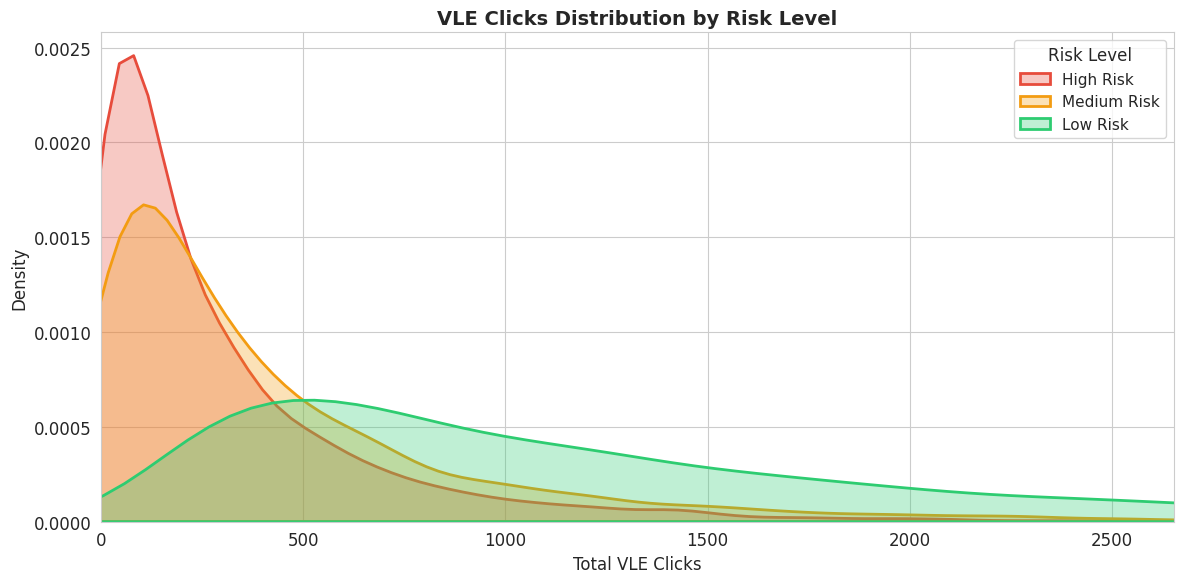

Saved: viz4_vle_clicks.png


In [ ]:
plt.figure(figsize=(12, 6))

risk_colors_map = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#2ecc71'}

for risk, color in risk_colors_map.items():
    subset = master_df[master_df['risk_level'] == risk]['total_clicks']
    subset = subset[subset > 0]
    sns.kdeplot(subset, label=risk, color=color, fill=True, alpha=0.3, linewidth=2)

plt.title('VLE Clicks Distribution by Risk Level', fontsize=14, fontweight='bold')
plt.xlabel('Total VLE Clicks')
plt.ylabel('Density')
plt.legend(title='Risk Level', fontsize=11)
plt.xlim(0, master_df['total_clicks'].quantile(0.95))
plt.tight_layout()
plt.savefig('/content/viz4_vle_clicks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz4_vle_clicks.png')

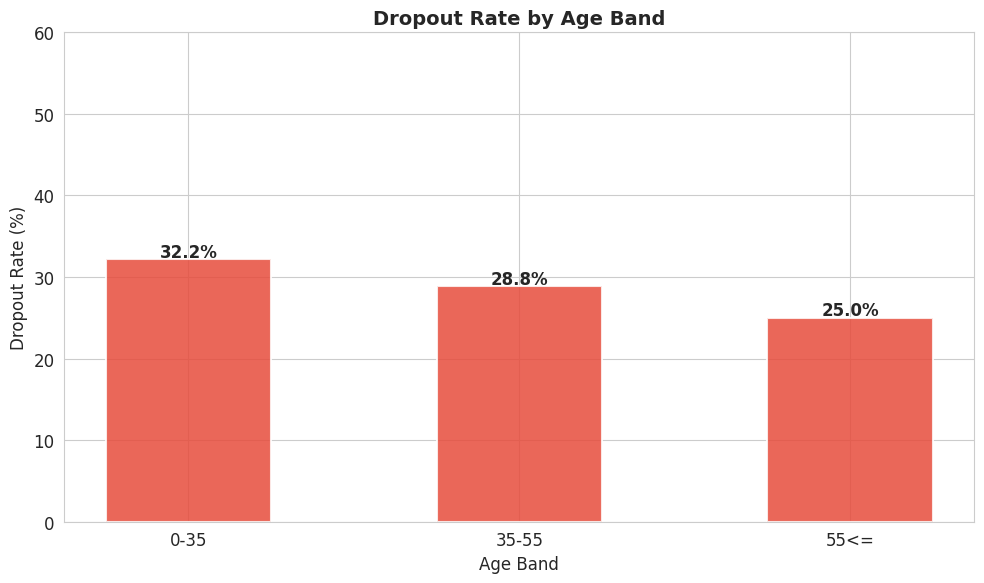

Saved: viz5_dropout_age.png


In [ ]:
dropout_by_age = master_df.groupby('age_band')['is_dropout'].mean() * 100
dropout_by_age = dropout_by_age.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(dropout_by_age.index, dropout_by_age.values,
               color='#e74c3c', edgecolor='white', linewidth=1.5, width=0.5, alpha=0.85)

for bar, val in zip(bars, dropout_by_age.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('Dropout Rate by Age Band', fontsize=14, fontweight='bold')
plt.xlabel('Age Band')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig('/content/viz5_dropout_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz5_dropout_age.png')

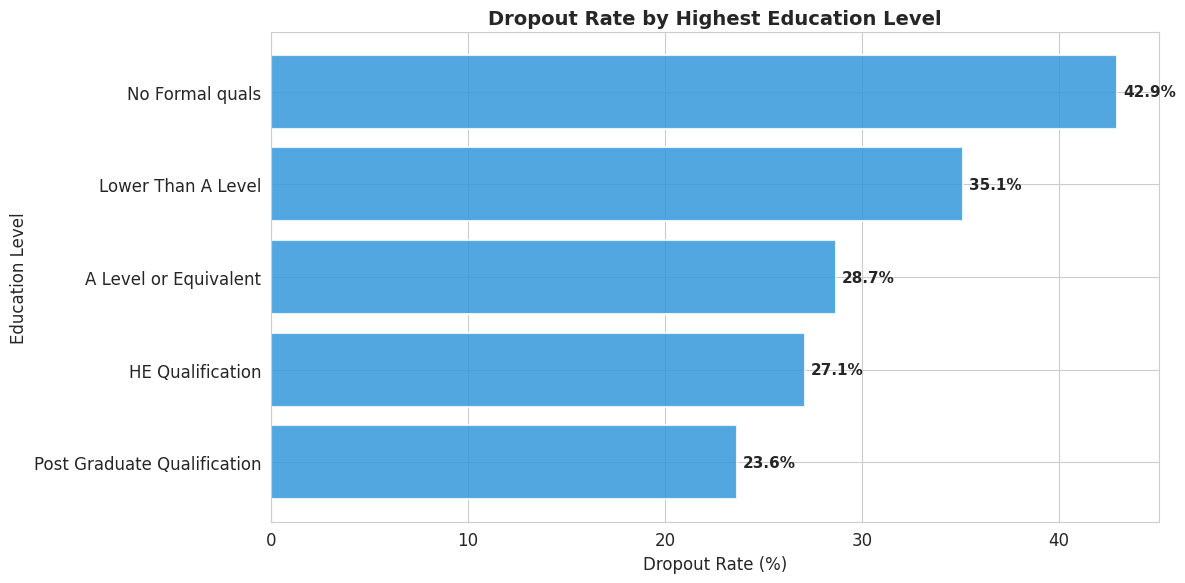

Saved: viz6_dropout_education.png


In [ ]:
dropout_by_edu = master_df.groupby('highest_education')['is_dropout'].mean() * 100
dropout_by_edu = dropout_by_edu.sort_values(ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(dropout_by_edu.index, dropout_by_edu.values,
                color='#3498db', edgecolor='white', linewidth=1.5, alpha=0.85)

for bar, val in zip(bars, dropout_by_edu.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.title('Dropout Rate by Highest Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Dropout Rate (%)')
plt.ylabel('Education Level')
plt.tight_layout()
plt.savefig('/content/viz6_dropout_education.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz6_dropout_education.png')

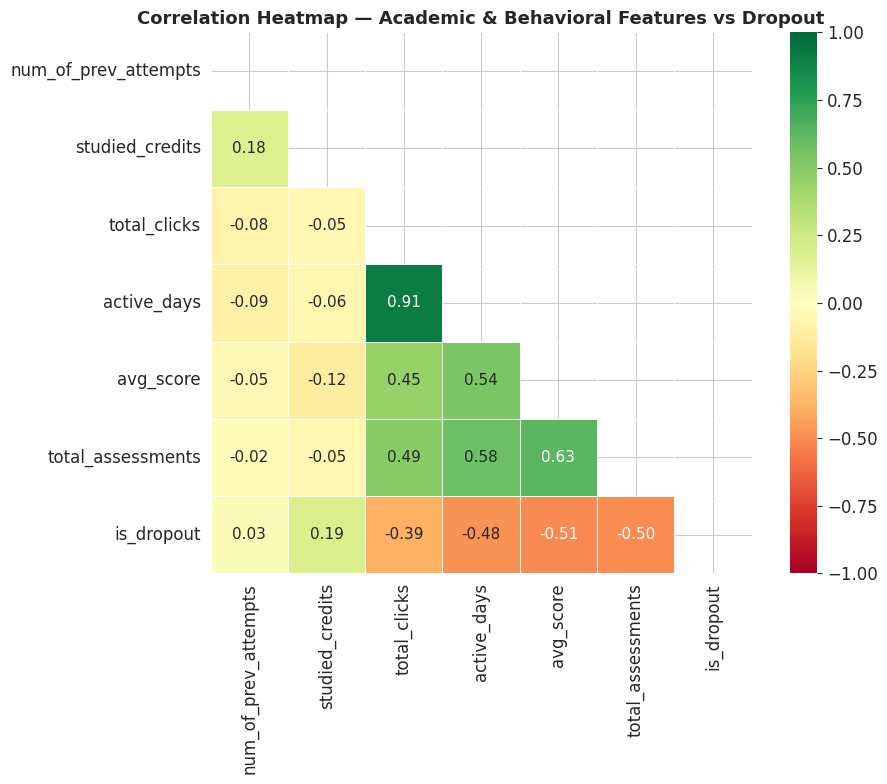

Saved: viz7_heatmap.png


In [ ]:
corr_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks',
             'active_days', 'avg_score', 'total_assessments', 'is_dropout']

corr_matrix = master_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True, annot_kws={'size': 11})

plt.title('Correlation Heatmap — Academic & Behavioral Features vs Dropout',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/viz7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz7_heatmap.png')

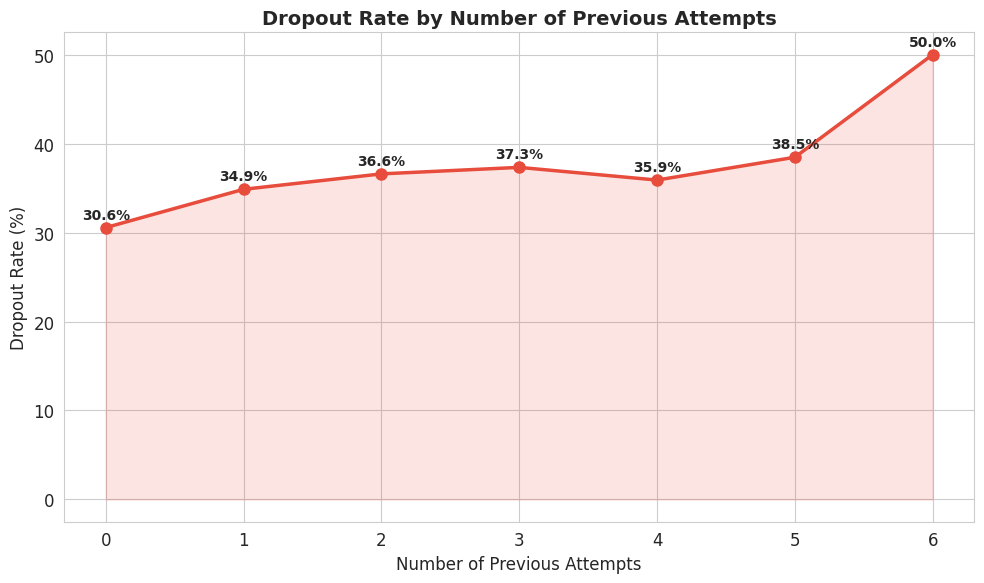

Saved: viz8_dropout_attempts.png


In [ ]:
dropout_by_attempts = master_df.groupby('num_of_prev_attempts')['is_dropout'].mean() * 100

plt.figure(figsize=(10, 6))
plt.plot(dropout_by_attempts.index, dropout_by_attempts.values,
         marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
plt.fill_between(dropout_by_attempts.index, dropout_by_attempts.values,
                 alpha=0.15, color='#e74c3c')

for x, y in zip(dropout_by_attempts.index, dropout_by_attempts.values):
    plt.text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Dropout Rate by Number of Previous Attempts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Dropout Rate (%)')
plt.xticks(dropout_by_attempts.index)
plt.tight_layout()
plt.savefig('/content/viz8_dropout_attempts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz8_dropout_attempts.png')

In [ ]:
print('=' * 55)
print('       DATA CLEANING SUMMARY REPORT')
print('=' * 55)
print(f'Dataset : OULAD (Open University Learning Analytics)')
print(f'Source  : https://analyse.kmi.open.ac.uk/open-dataset')
print(f'License : CC-BY 4.0 (Open, Ethical)')
print()
print('Files Loaded:')
print(f'  studentInfo.csv         : {student_info.shape[0]:,} rows')
print(f'  studentVle.csv          : {student_vle.shape[0]:,} rows')
print(f'  studentAssessment.csv   : {student_assessment.shape[0]:,} rows')
print(f'  studentRegistration.csv : {student_reg.shape[0]:,} rows')
print(f'  assessments.csv         : {assessments.shape[0]:,} rows')
print(f'  vle.csv                 : {vle.shape[0]:,} rows')
print(f'  courses.csv             : {courses.shape[0]:,} rows')
print()
print(f'Total rows (all files)   : {total_rows:,}')
print(f'Minimum requirement      : 500,000 rows')
print(f'Requirement met          : YES ✓')
print()
print('Cleaning Steps Applied:')
print('  1. Removed duplicate rows')
print('  2. Handled missing values (fillna / dropna)')
print('  3. Removed invalid score values (outside 0-100)')
print('  4. Removed zero/null VLE clicks')
print('  5. Removed outliers using IQR method')
print('  6. Created is_dropout binary label')
print('  7. Created risk_level classification column')
print('  8. Merged all files into one master dataset')
print()
print(f'Final Master Dataset     : {master_df.shape[0]:,} rows x {master_df.shape[1]} cols')
print(f'Saved as                 : oulad_cleaned_master.csv')
print()
print('Visualizations Generated : 8 charts saved as PNG')
print('=' * 55)

       DATA CLEANING SUMMARY REPORT
Dataset : OULAD (Open University Learning Analytics)
Source  : https://analyse.kmi.open.ac.uk/open-dataset
License : CC-BY 4.0 (Open, Ethical)

Files Loaded:
  studentInfo.csv         : 32,593 rows
  studentVle.csv          : 10,655,280 rows
  studentAssessment.csv   : 173,912 rows
  studentRegistration.csv : 32,593 rows
  assessments.csv         : 206 rows
  vle.csv                 : 6,364 rows
  courses.csv             : 22 rows

Total rows (all files)   : 10,900,970
Minimum requirement      : 500,000 rows
Requirement met          : YES ✓

Cleaning Steps Applied:
  1. Removed duplicate rows
  2. Handled missing values (fillna / dropna)
  3. Removed invalid score values (outside 0-100)
  4. Removed zero/null VLE clicks
  5. Removed outliers using IQR method
  6. Created is_dropout binary label
  7. Created risk_level classification column
  8. Merged all files into one master dataset

Final Master Dataset     : 32,593 rows x 19 cols
Saved as        